# Example of the aitlas toolbox in the context of multi class image classification

## Import the required packages

In [ ]:
from aitlas.datasets import BrazilianCoffeeScenesDataset
from aitlas.models import VisionTransformer
from aitlas.transforms import ResizeCenterCropFlipHVToTensor, ResizeCenterCropToTensor, ResizeRandomCropFlipHVToTensor
from aitlas.utils import image_loader

## Load the dataset

In [15]:
dataset_config = {
    "data_dir": "/home/dragik/data/brazilian_coffee_scenes/",
    "csv_file": "/home/dragik/data/brazilian_coffee_scenes/train.csv"
}
dataset = BrazilianCoffeeScenesDataset(dataset_config)
print(f"Total number of patches: {len(dataset)}")

Total number of patches: 2302


## Show images from the dataset

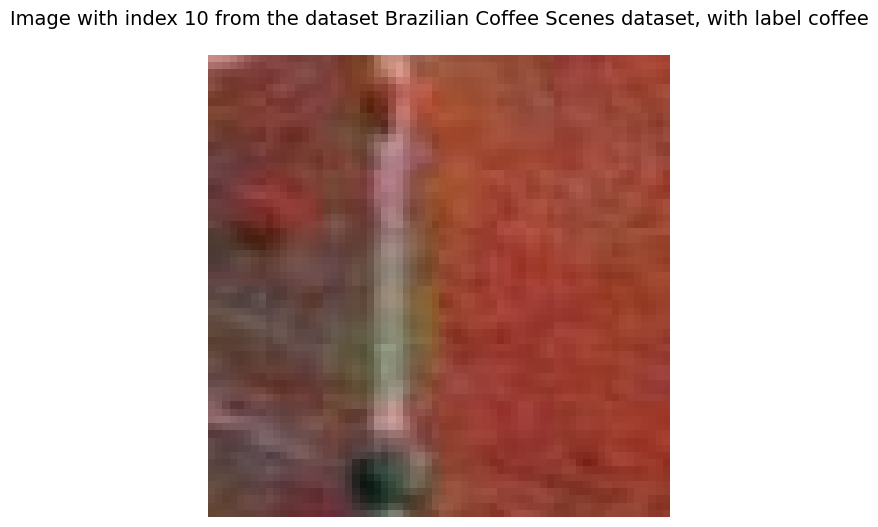

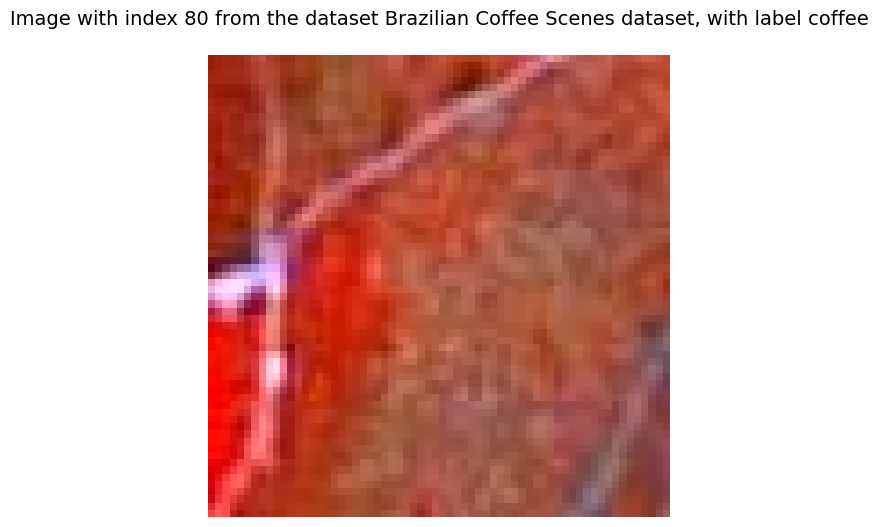

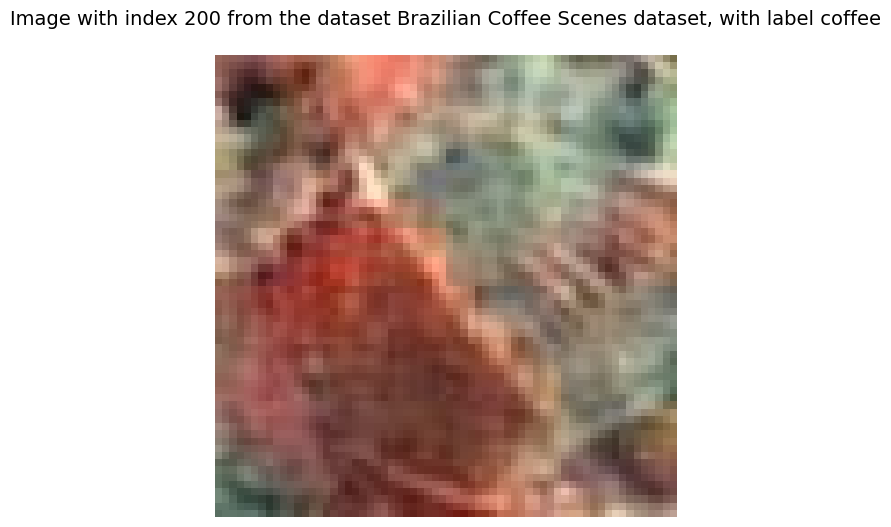

In [16]:
fig1 = dataset.show_image(10)
fig2 = dataset.show_image(80)
fig3 = dataset.show_image(200)

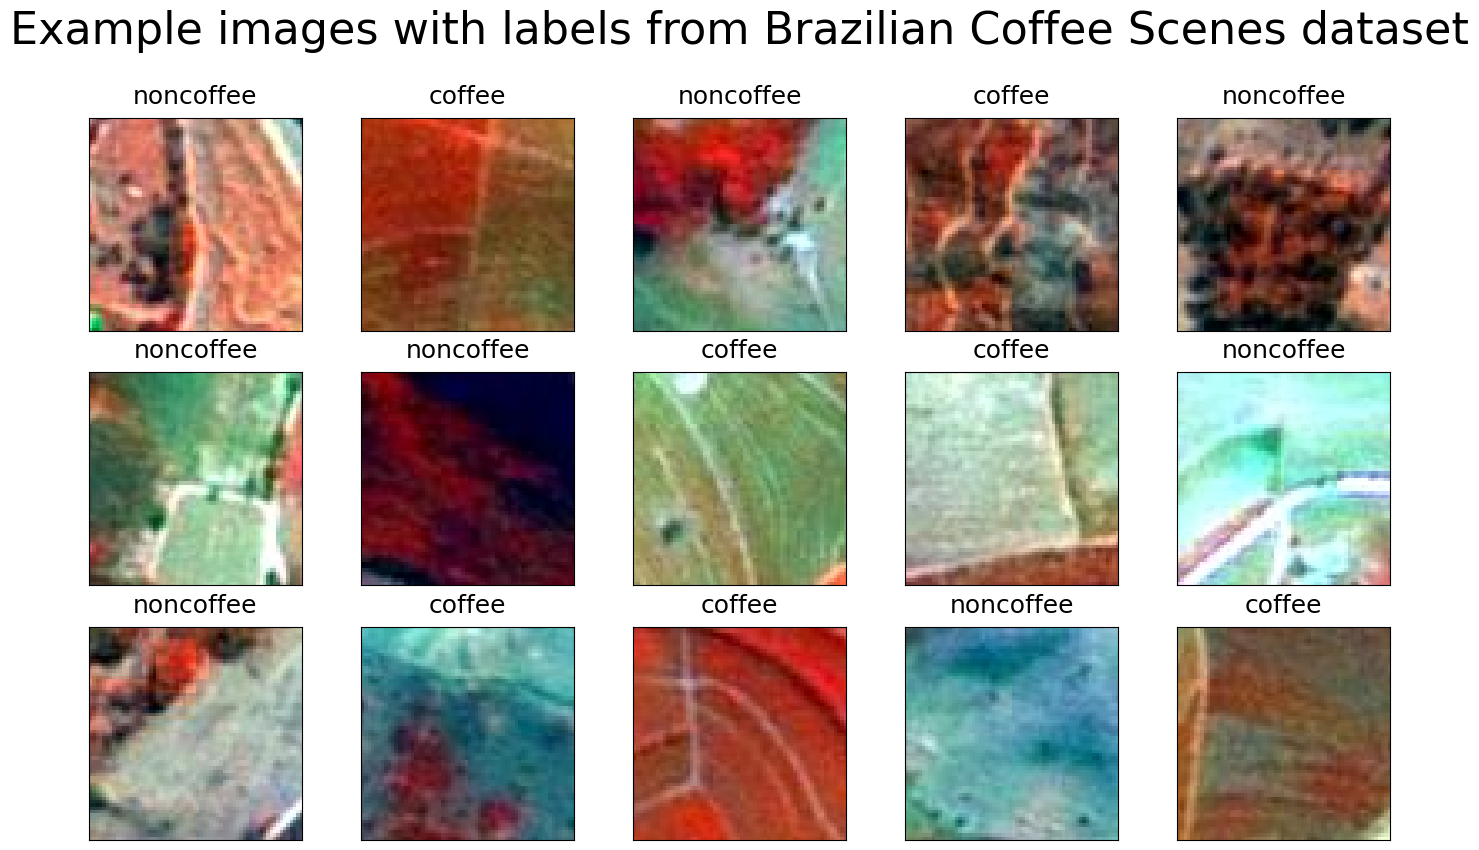

In [17]:
fig4 = dataset.show_batch(15)

## Inspect the data

In [18]:
dataset.data_distribution_table()

,Label,Count
0,coffee,1162
1,noncoffee,1140


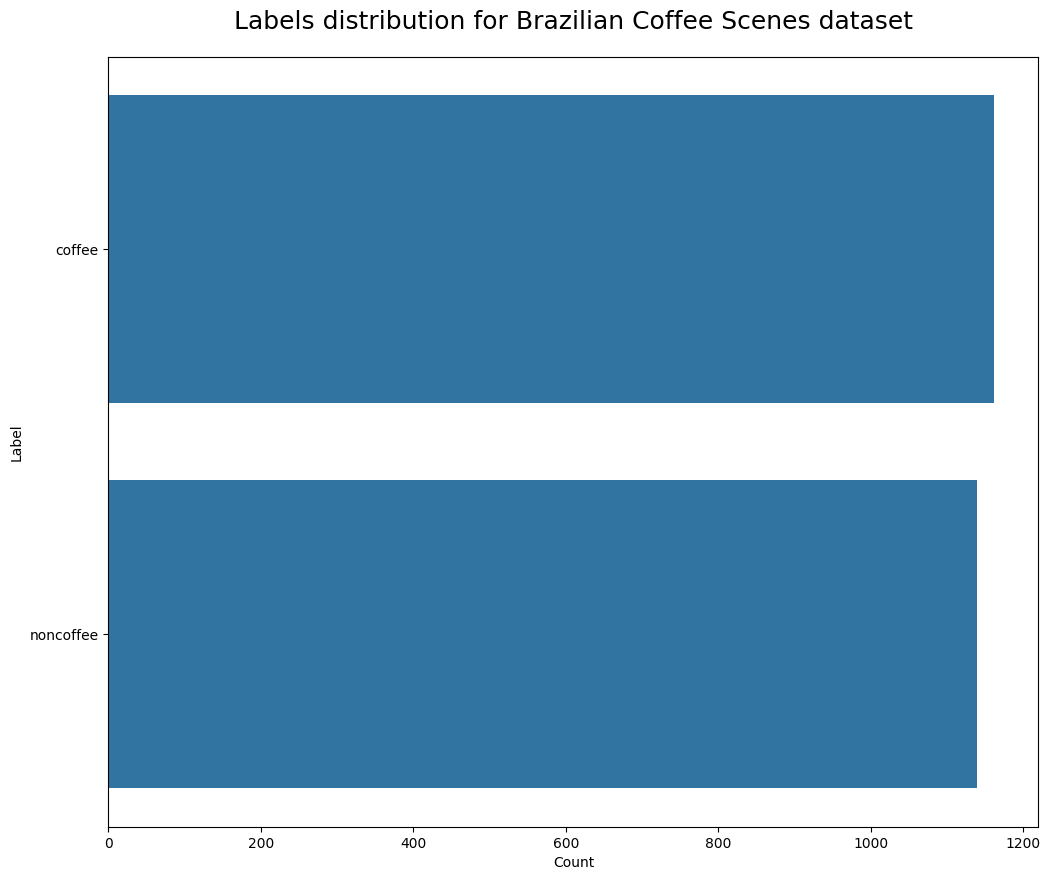

In [19]:
fig = dataset.data_distribution_barchart()

## Load train and validation splits

In [21]:
train_dataset_config = {
    "batch_size": 32,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/brazilian_coffee_scenes/",
    "csv_file": "/home/dragik/data/brazilian_coffee_scenes/train.csv"
}

train_dataset = BrazilianCoffeeScenesDataset(train_dataset_config)
train_dataset.transform = ResizeRandomCropFlipHVToTensor() 

validation_dataset_config = {
    "batch_size": 32,
    "shuffle": False,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/brazilian_coffee_scenes/",
    "csv_file": "/home/dragik/data/brazilian_coffee_scenes/val.csv",
    "transforms": ["aitlas.transforms.ResizeCenterCropToTensor"]
}

validation_dataset = BrazilianCoffeeScenesDataset(validation_dataset_config)
len(train_dataset), len(validation_dataset)

(2302, 287)

## Setup and create the model for training

In [22]:
epochs = 10
model_directory = "/home/dragik/data/experiments/brazilian_coffee_scenes/"
model_config = {
    "num_classes": 2, 
    "learning_rate": 0.0001,
    "pretrained": True,
    "metrics": ["accuracy", "precision", "recall", "f1_score"]
}
model = VisionTransformer(model_config)
model.prepare()

2025-11-11 12:00:34,714 INFO Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2025-11-11 12:00:35,038 INFO [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


## Training and validation

In [23]:
model.train_and_evaluate_model(
    train_dataset=train_dataset,
    epochs=epochs,
    model_directory=model_directory,
    val_dataset=validation_dataset,
    run_id='1',
)

2025-11-11 12:00:49,631 INFO Starting training.
training: 100%|██████████| 72/72 [00:41<00:00,  1.74it/s]
2025-11-11 12:01:31,310 INFO epoch: 1, time: 42, loss:  0.35097
testing on train set: 100%|██████████| 72/72 [00:15<00:00,  4.71it/s]
2025-11-11 12:01:48,638 INFO Accuracy:0.924847958297133, Precision Micro:0.924847958297133, Precision Macro:0.9267722510804443, Precision Weighted:0.9265202603588202, Precision per Class:[0.90040486 0.95313964], Recall Micro:0.924847958297133, Recall Macro:0.9245380016305824, Recall Weighted:0.924847958297133, Recall per Class:[0.95697074 0.89210526], F1_score Micro:0.9248479582971324, F1_score Macro:0.9247197495585683, F1_score Weighted:0.9247494400032884, F1_score per Class:[0.92782645 0.92161305]
testing on validation set: 100%|██████████| 9/9 [00:02<00:00,  4.06it/s]
2025-11-11 12:01:50,869 INFO Accuracy:0.8815331010452961, Precision Micro:0.8815331010452961, Precision Macro:0.8817387081107333, Precision Weighted:0.8823555293070449, Precision per

0.10420370546633217

## Predictions

2025-11-11 12:25:17,486 INFO Loading checkpoint /home/dragik/data/experiments/brazilian_coffee_scenes/checkpoint.pth.tar
2025-11-11 12:25:18,456 INFO Loaded checkpoint /home/dragik/data/experiments/brazilian_coffee_scenes/checkpoint.pth.tar at epoch 11


The amount of images for testing is 287


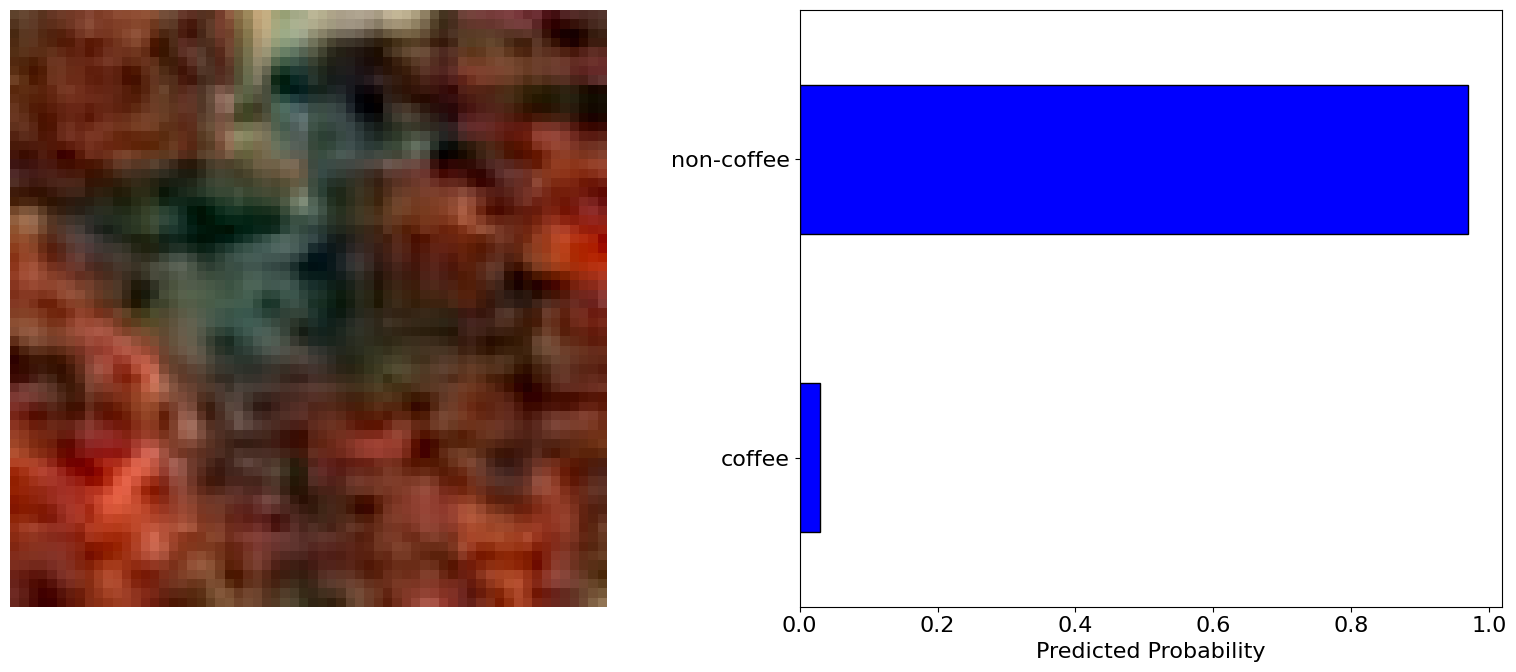

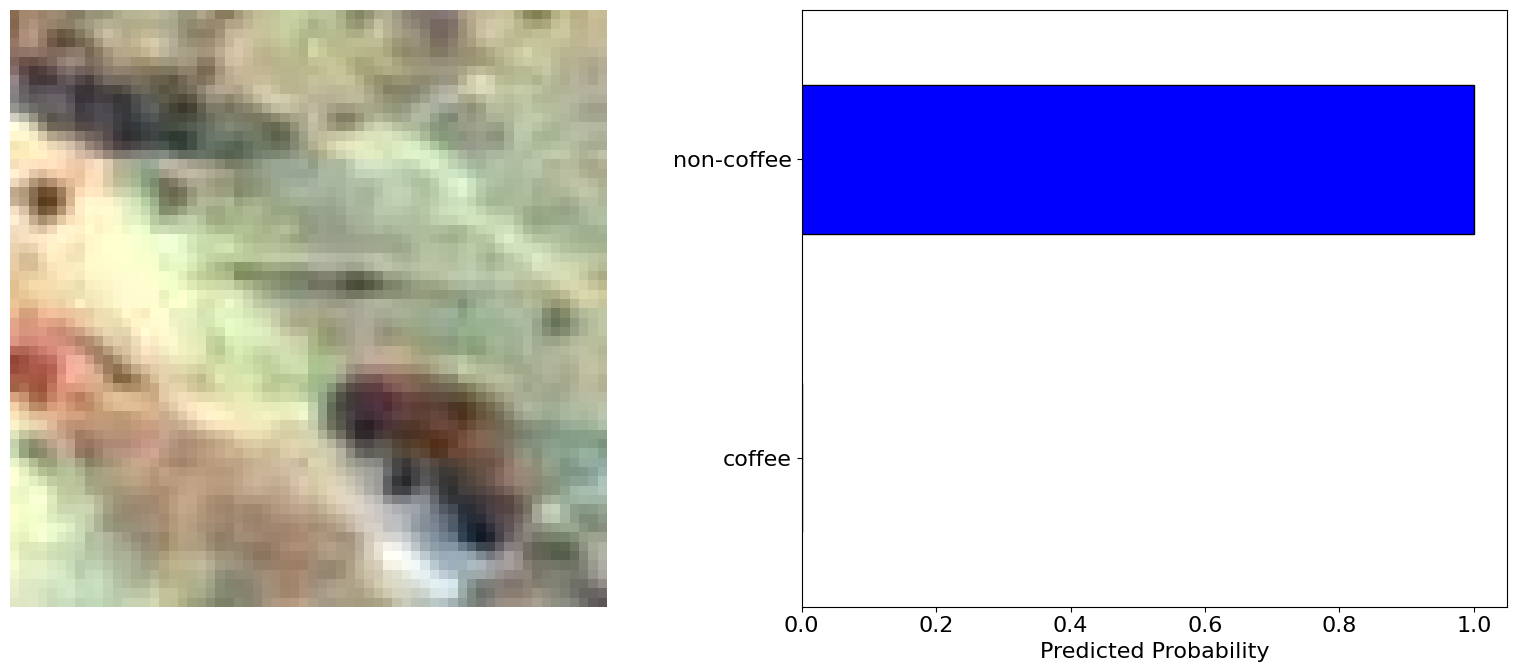

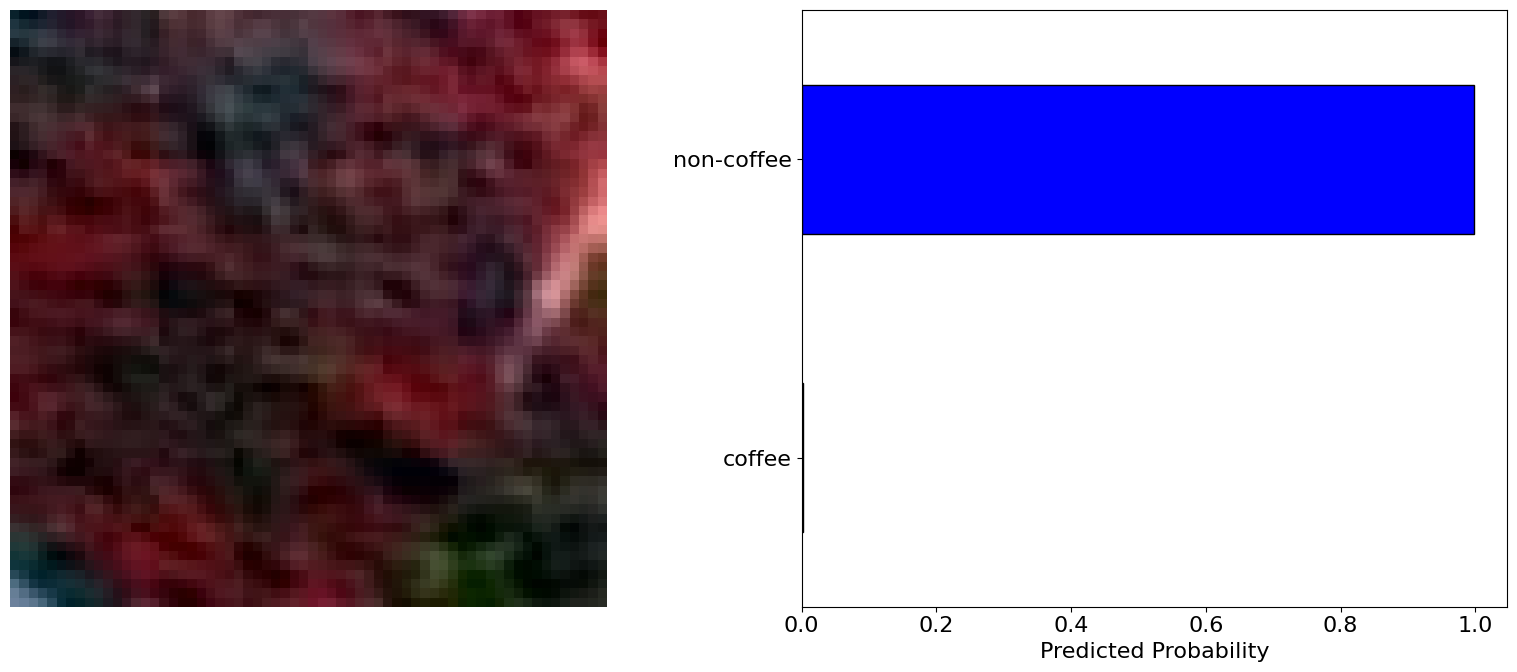

In [24]:
labels = ["coffee","non-coffee"]
transform = ResizeCenterCropToTensor()

model_path = "/home/dragik/data/experiments/brazilian_coffee_scenes/checkpoint.pth.tar"
model.load_model(model_path)

test_dataset_config = {
    "data_dir": "/home/dragik/data/brazilian_coffee_scenes/",
    "csv_file": "/home/dragik/data/brazilian_coffee_scenes/test.csv",
}

test_dataset = BrazilianCoffeeScenesDataset(test_dataset_config)
print(f'The amount of images for testing is {len(test_dataset)}')

image = test_dataset[0][0]
fig = model.predict_image(image, labels, transform)

image = test_dataset[10][0]
fig = model.predict_image(image, labels, transform)

image = test_dataset[100][0]
fig = model.predict_image(image, labels, transform)